In [1]:
# Customer Segmentation Using RFM Analysis

## Project Overview
This add-on analysis segments ecommerce customers using Recency, Frequency, and Monetary (RFM) metrics. The goal is to identify high-value customers, loyal customers, at-risk customers, and re-engagement opportunities.

## Business Question
How can the company better understand customer behavior and target different customer groups more effectively?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/raw/ecommerce_transactions.csv", encoding="ISO-8859-1")
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], errors='coerce')
df['Revenue'] = df['Quantity'] * df['UnitPrice']

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [3]:
# remove returns
df = df[df['Quantity'] > 0]

# remove invalid prices
df = df[df['UnitPrice'] > 0]

# remove missing customer IDs
df = df.dropna(subset=['CustomerID'])

df.shape

(397884, 9)

In [4]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'Revenue': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [5]:
rfm['R_score'] = pd.qcut(rfm['Recency'], 4, labels=[4, 3, 2, 1])
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 4, labels=[1, 2, 3, 4])
rfm['M_score'] = pd.qcut(rfm['Monetary'], 4, labels=[1, 2, 3, 4])

rfm.head()

,Recency,Frequency,Monetary,R_score,F_score,M_score
CustomerID,,,,,,
12346.0,326,1,77183.60,1,1,4
12347.0,2,7,4310.00,4,4,4
12348.0,75,4,1797.24,2,3,4
12349.0,19,1,1757.55,3,1,4
12350.0,310,1,334.40,1,1,2


In [ ]:
## Customer Segments
The chart below shows the distribution of customers across RFM-based segments.

In [6]:
rfm['R_score'] = rfm['R_score'].astype(int)
rfm['F_score'] = rfm['F_score'].astype(int)
rfm['M_score'] = rfm['M_score'].astype(int)

def segment_customer(row):
    if row['R_score'] == 4 and row['F_score'] == 4:
        return 'Champions'
    elif row['F_score'] >= 3:
        return 'Loyal Customers'
    elif row['R_score'] >= 3 and row['F_score'] <= 2:
        return 'Potential Loyalists'
    elif row['R_score'] <= 2 and row['F_score'] >= 3:
        return 'At Risk'
    else:
        return 'Lost Customers'

rfm['Segment'] = rfm.apply(segment_customer, axis=1)

rfm['Segment'].value_counts()

Segment
Loyal Customers        1560
Lost Customers         1504
Potential Loyalists     665
Champions               609
Name: count, dtype: int64

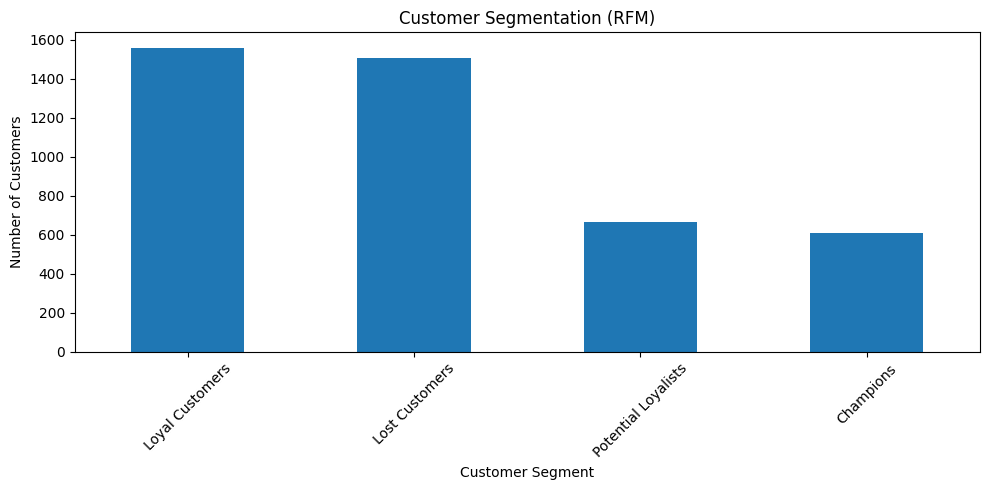

In [7]:
segment_counts = rfm['Segment'].value_counts()

plt.figure(figsize=(10, 5))
segment_counts.plot(kind='bar')
plt.title("Customer Segmentation (RFM)")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../images/customer_segments.png")
plt.show()

In [ ]:
## Key Insights

- Champions are the most valuable customers because they purchase recently, frequently, and spend the most.
- Loyal Customers represent a stable revenue base and should be retained through ongoing engagement.
- Potential Loyalists may become repeat buyers with the right promotions.
- At Risk customers may need reactivation campaigns before they churn.
- Lost Customers are candidates for re-engagement or may no longer be worth active marketing spend.

## Recommendations

- Reward Champions with exclusive offers or loyalty incentives.
- Target Potential Loyalists with personalized follow-up promotions.
- Re-engage At Risk customers with timed discounts or reminders.
- Review whether Lost Customers should be targeted again or deprioritized.